# **Generador de Arte Abstracto para Etiquetas de Vino (WineArtGAN)**

Consiste en abordar una tarea de generación de imágenes. El objetivo es entrenar y realizar el fine-tuning de una arquitectura generativa (como una Red Generativa Antagónica o un modelo de Difusión) para crear obras de arte abstracto inéditas. El dominio de aplicación está enfocado en generar diseños estéticos para utilizarlos en etiquetas de vino locales.


# **A) Carga y organización del dataset**

Instalación de KaggleHub

In [ ]:
!pip install kagglehub

Descarga del dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "bryanb/abstract-art-gallery"
)

print("Dataset descargado en:", path)

100%|██████████| 693M/693M [00:09<00:00, 75.3MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22


El dataset se descarga desde Kaggle utilizando kagglehub. Una vez descargado, queda almacenado en una ruta local de Colab, desde donde se accede a las imágenes para su posterior procesamiento.

**Estructura original del dataset**

Luego de descargar el dataset desde Kaggle con `kagglehub`, se observa una estructura similar a la siguiente:

```text
abstract-art-gallery/

├── Abstract_gallery/
│   └── Abstract_gallery/
│       ├── Abstract_image_1.jpg
│       ├── Abstract_image_2.jpg
│       └── ...

└── Abstract_gallery_2/
    └── Abstract_gallery_2/
        ├── Abstract_image_2801.jpg
        ├── Abstract_image_2802.jpg
        └── ...
```

Este dataset no posee etiquetas de clasificación. Las imágenes representan obras de arte abstracto sin categorías asociadas. Como el objetivo del proyecto es la generación de imágenes, el modelo aprende directamente la distribución visual del conjunto completo y cada muestra del dataset corresponde únicamente a una imagen.

Inspeccionamos el dataset

In [ ]:
from pathlib import Path

files = list(Path(path).rglob("*"))

print("Cantidad total:", len(files))

for file in files[:10]:
    print(file)

Cantidad total: 2876
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery/Abstract_gallery
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2807.jpg
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2824.jpg
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2805.jpg
/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2860.jpg
/root/.cache/kagglehub/datasets/bryanb/abstract

El dataset descargado contiene carpetas como Abstract_gallery y Abstract_gallery_2, dentro de las cuales se encuentran las imágenes de arte abstracto en formato .jpg.

**Acceso a las imágenes**

In [ ]:
image_files = list(Path(path).rglob("*.jpg"))

print("Cantidad de imágenes encontradas:", len(image_files))
print(image_files[:5])

Cantidad de imágenes encontradas: 2872
[PosixPath('/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2807.jpg'), PosixPath('/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2824.jpg'), PosixPath('/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2805.jpg'), PosixPath('/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2860.jpg'), PosixPath('/root/.cache/kagglehub/datasets/bryanb/abstract-art-gallery/versions/22/Abstract_gallery_2/Abstract_gallery_2/Abstract_image_2823.jpg')]


Se buscan recursivamente todos los archivos con extensión .jpg. Esto permite acceder a todas las imágenes del dataset, aunque estén distribuidas en distintas subcarpetas.

**Visualización de una imagen de ejemplo**

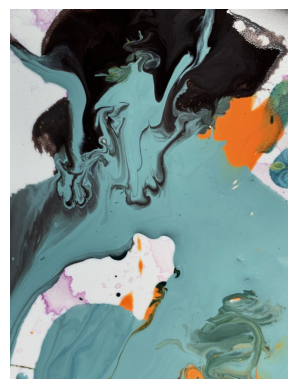

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_files[0]).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

Se carga una imagen con PIL y se convierte a formato RGB para asegurar que todas las imágenes tengan tres canales de color.

**Clase Dataset de PyTorch**

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class AbstractArtDataset(Dataset):

    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(
            self.image_paths[idx]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

Se implementa una clase personalizada heredando de torch.utils.data.Dataset. No se utiliza ImageFolder porque este dataset no está organizado por clases, ya que el problema no es de clasificación sino de generación de imágenes. Por lo tanto, cada muestra del dataset es únicamente una imagen, sin etiqueta asociada.

**Transformación básica para poder cargar las imágenes**

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

**Partición train / val / test**

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

train_paths, temp_paths = train_test_split(
    image_files,
    test_size=0.10,
    random_state=SEED
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.50,
    random_state=SEED
)

print("Cantidad total de imágenes:", len(image_files))
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Cantidad total de imágenes: 2872
Train: 2584
Validation: 144
Test: 144


**Creación de datasets**

In [ ]:
train_dataset = AbstractArtDataset(
    train_paths,
    transform=transform
)

val_dataset = AbstractArtDataset(
    val_paths,
    transform=transform
)

test_dataset = AbstractArtDataset(
    test_paths,
    transform=transform
)

**Creación de DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batches train:", len(train_loader))
print("Batches val:", len(val_loader))
print("Batches test:", len(test_loader))

Batches train: 81
Batches val: 5
Batches test: 5


Se crean tres DataLoader: uno para entrenamiento, uno para validación y uno para test. En train_loader se usa shuffle=True para mezclar las imágenes durante el entrenamiento. En validación y test se utiliza shuffle=False, ya que estos conjuntos se usan para evaluar de forma más estable.

# **B) Particionado**

El dataset se dividió en tres conjuntos: train, validación y test. Como el problema es de generación de imágenes, las muestras no poseen etiquetas ni clases asociadas. Por lo tanto, no se realiza una distribución por clase como en un problema de clasificación.

Se utilizó una división de 90% para entrenamiento, 5% para validación y 5% para test. El conjunto de entrenamiento se usará para entrenar el modelo generativo, mientras que validación y test se reservarán para observar la calidad de las imágenes generadas y evaluar la evolución del modelo.

Para asegurar que la división sea reproducible, se fijó una semilla:



```
# SEED = 42
```



ESTA CELDA SE EJECUTA ARRIBA VERIFICAR SI VA ACA

In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

train_paths, temp_paths = train_test_split(
    image_files,
    test_size=0.10,
    random_state=SEED
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.50,
    random_state=SEED
)

print("Cantidad total de imágenes:", len(image_files))
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Cantidad total de imágenes: 2872
Train: 2584
Validation: 144
Test: 144


Se eligió una división 90/5/5 porque el objetivo principal es entrenar un modelo generativo, por lo que conviene utilizar la mayor cantidad posible de imágenes para que el modelo aprenda mejor la distribución visual del dataset. A diferencia de un problema de clasificación, no se requiere mantener una distribución por clase, ya que las imágenes no poseen etiquetas. Los conjuntos de validación y test se reservan para comparar resultados generados durante el entrenamiento y analizar la calidad visual final.

# **C) Preprocesamiento**

Las imágenes del dataset se preprocesan antes de ser entregadas al modelo. Primero se convierten a formato RGB, para asegurar que todas tengan tres canales de color. Luego se redimensionan a 64x64 píxeles, tamaño adecuado para entrenar una DCGAN de manera eficiente en Colab.

Después, las imágenes se convierten a tensores de PyTorch y se normalizan al rango [-1, 1] usando media [0.5, 0.5, 0.5] y desvío [0.5, 0.5, 0.5]. Esta normalización es adecuada para modelos generativos con salida tanh.

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

Verificación del preprocesamiento

In [ ]:
sample = train_dataset[0]

print("Dimensiones:", sample.shape)
print("Valor mínimo:", sample.min().item())
print("Valor máximo:", sample.max().item())

Dimensiones: torch.Size([3, 64, 64])
Valor mínimo: 0.0313725508749485
Valor máximo: 0.886274516582489


Para el preprocesamiento se redimensionaron todas las imágenes a 64x64 píxeles, ya que se trabajará con una arquitectura generativa tipo DCGAN. Además, todas las imágenes se convierten a RGB para asegurar tres canales de color. Luego se transforman a tensores y se normalizan al rango [-1,1], utilizando media y desvío de 0.5 en cada canal. Esta normalización es adecuada para redes generativas, ya que el generador suele utilizar una activación tanh en la capa de salida.

# **d) Data augmentation**

Para el conjunto de entrenamiento se aplican transformaciones de aumento de datos con el objetivo de incrementar la variabilidad visual del dataset y mejorar la capacidad de generalización del modelo generativo.

Como el problema consiste en generar arte abstracto, se utilizan augmentations suaves que no modifican la naturaleza de la imagen:

RandomHorizontalFlip: invierte horizontalmente algunas imágenes.
RandomRotation: aplica pequeñas rotaciones.
ColorJitter: modifica levemente brillo, contraste y saturación.
Resize: lleva todas las imágenes al tamaño esperado por el modelo.
ToTensor y Normalize: convierten la imagen a tensor y normalizan al rango adecuado.

Estas transformaciones tienen sentido porque en arte abstracto una rotación leve, un cambio de color o una inversión horizontal siguen conservando el estilo visual de la obra.

Las augmentations se aplican solo al conjunto de entrenamiento. En validación y test no se aplican augmentations aleatorias, para poder evaluar los resultados de forma consistente.

**Transformaciones para train**

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

**Transformaciones para validación y test**

In [ ]:
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

**Crear datasets usando transformaciones distintas**

In [ ]:
train_dataset = AbstractArtDataset(
    train_paths,
    transform=train_transform
)

val_dataset = AbstractArtDataset(
    val_paths,
    transform=eval_transform
)

test_dataset = AbstractArtDataset(
    test_paths,
    transform=eval_transform
)

**Mostrar visualmente el efecto de las augmentations**

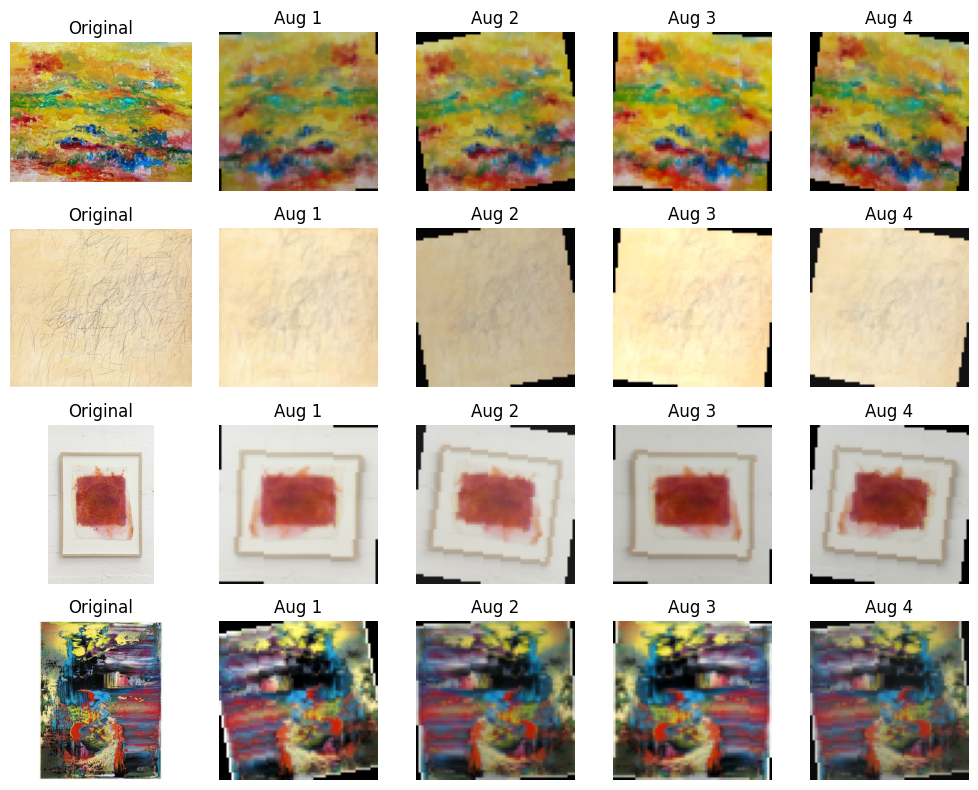

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5
    return tensor.clamp(0, 1)

sample_paths = train_paths[:4]

fig, axes = plt.subplots(
    len(sample_paths),
    5,
    figsize=(10, 8)
)

for row, img_path in enumerate(sample_paths):
    original_img = Image.open(img_path).convert("RGB")

    axes[row, 0].imshow(original_img)
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    for col in range(1, 5):
        augmented_img = train_transform(original_img)
        augmented_img = denormalize(augmented_img)
        augmented_img = augmented_img.permute(1, 2, 0)

        axes[row, col].imshow(augmented_img)
        axes[row, col].set_title(f"Aug {col}")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

Las augmentations se aplican solamente al conjunto de entrenamiento, porque el objetivo es aumentar la variabilidad visual durante el aprendizaje. En validación y test se usan transformaciones determinísticas, sin cambios aleatorios, para evaluar siempre sobre imágenes consistentes. En este problema se usaron transformaciones suaves, como rotación leve, inversión horizontal y cambios moderados de color, porque en arte abstracto esas modificaciones mantienen la esencia visual de la obra.

# **e) Verificación final**

Para verificar que el pipeline de datos funciona correctamente, se toma un batch del train_loader y se inspeccionan sus dimensiones y rango de valores. Como el problema es generativo, cada muestra contiene únicamente una imagen, sin etiqueta asociada.

También se visualizan algunas imágenes del batch desnormalizadas, para confirmar que el preprocesamiento y las transformaciones se aplicaron correctamente.

In [ ]:
batch = next(iter(train_loader))

print("Tipo del batch:", type(batch))
print("Dimensiones del batch:", batch.shape)
print("Valor mínimo:", batch.min().item())
print("Valor máximo:", batch.max().item())

Tipo del batch: <class 'torch.Tensor'>
Dimensiones del batch: torch.Size([32, 3, 64, 64])
Valor mínimo: 0.0
Valor máximo: 1.0


**Desnormalizar y visualizar**

Como las imágenes están normalizadas en el rango [-1, 1], para mostrarlas hay que desnormalizarlas al rango [0, 1].

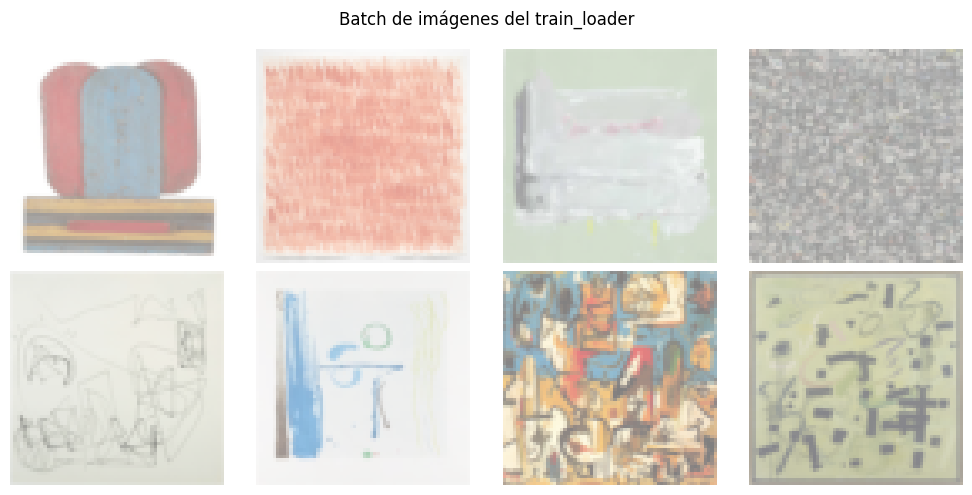

In [ ]:
import matplotlib.pyplot as plt

def denormalize(tensor):
    return tensor * 0.5 + 0.5

images = batch[:8]

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)
    img = img.clamp(0, 1)

    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Batch de imágenes del train_loader")
plt.tight_layout()
plt.show()

Se observa un batch de imágenes proveniente del train_loader. El tensor tiene dimensiones [32, 3, 64, 64], donde 32 corresponde al tamaño del batch, 3 a los canales RGB, y 64x64 al tamaño final de cada imagen. El rango de valores se encuentra aproximadamente entre -1 y 1 debido a la normalización aplicada. Para visualizar las imágenes, se realiza una desnormalización al rango [0,1]. Como el proyecto corresponde a generación de imágenes, no existen etiquetas asociadas a cada imagen.

# **f) Repositorio de GitHub**

**Código para generar los CSV**

In [ ]:
import pandas as pd
from pathlib import Path

repo_data_dir = Path("data")
repo_data_dir.mkdir(exist_ok=True)

def save_split_csv(paths, filename, base_path):
    rows = []

    for p in paths:
        rows.append({
            "image_path": str(Path(p).relative_to(base_path)),
            "label": "abstract_art"
        })

    df = pd.DataFrame(rows)
    df.to_csv(repo_data_dir / filename, index=False)

save_split_csv(train_paths, "train.csv", Path(path))
save_split_csv(val_paths, "val.csv", Path(path))
save_split_csv(test_paths, "test.csv", Path(path))

print("CSV generados correctamente.")

CSV generados correctamente.


In [ ]:
!ls data

test.csv  train.csv  val.csv


In [ ]:
from google.colab import files

files.download("data/train.csv")
files.download("data/val.csv")
files.download("data/test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>